In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import seaborn as sns
from tabulate import tabulate

os.environ['PATH'] += ':/Library/TeX/texbin'

plt.rcParams.update({
    "text.usetex": True,
})

In [5]:
results_paths: dict = {
    "ablation_dense": "../data/exp2_ablation_dense.csv",
    "ablation_sparse": "../data/exp2_ablation_sparse.csv",
    "toysim": "../data/exp2_toysim.csv",
}

In [13]:
data_frames = {key: pd.read_csv(path) for key, path in results_paths.items()}

for key, df in data_frames.items():
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    df = df.loc[:, (df.nunique() > 1)]
    print(f"Data Frame Head for {key}")
    print(tabulate(df.head(), headers='keys', tablefmt='psql'))
    
    # Print unique values in each column, excluding 'test_auc' and 'test_nll'
    exclude_cols = ['test_auc', 'test_nll']
    for col in df.columns:
        if len(df[col].unique()) > 1 and col not in exclude_cols:  
            print(f"Unique Values in Column '{col}':")
            unique_values = pd.DataFrame({'Value': df[col].unique()})
            print(tabulate(unique_values, headers='keys', tablefmt='psql'))

    data_frames[key] = df

Data Frame Head for ablation_dense
+----+------------+------------+-------------+-------------------+-----------------------+-------------------------+
|    |   test_nll |   test_auc |   num_tiles |   axis_resolution |   vector_length_scale |   vector_dimensionality |
|----+------------+------------+-------------+-------------------+-----------------------+-------------------------|
|  0 |   0.208333 |   0.987646 |           1 |               0.1 |                   0.1 |                   32768 |
|  1 |   0.187242 |   0.990342 |           2 |               0.1 |                   0.1 |                   32768 |
|  2 |   0.222224 |   0.985254 |           4 |               0.1 |                   0.1 |                   32768 |
|  3 |   0.18605  |   0.990933 |           8 |               0.1 |                   0.1 |                   32768 |
|  4 |   0.128498 |   0.992881 |           1 |               0.1 |                   0.2 |                   32768 |
+----+------------+----------

---
## Plot a correlation map for each dataframe
---

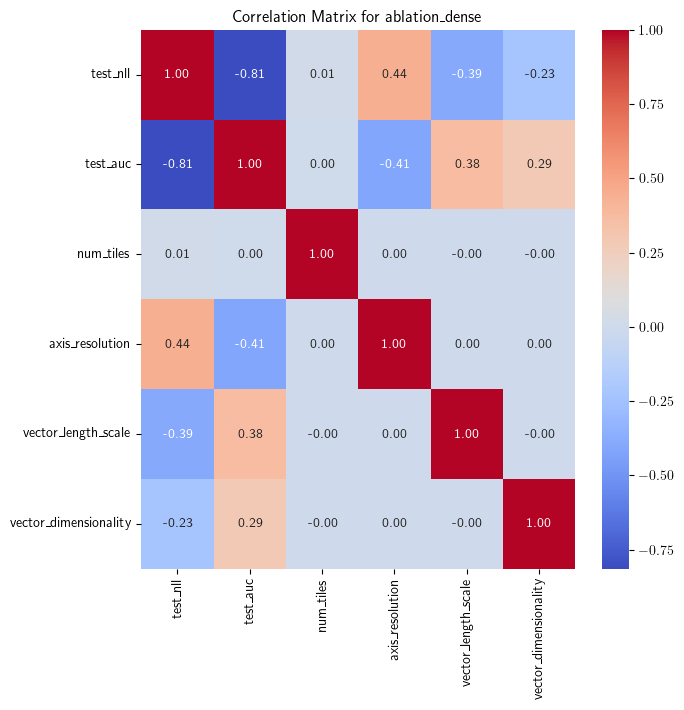

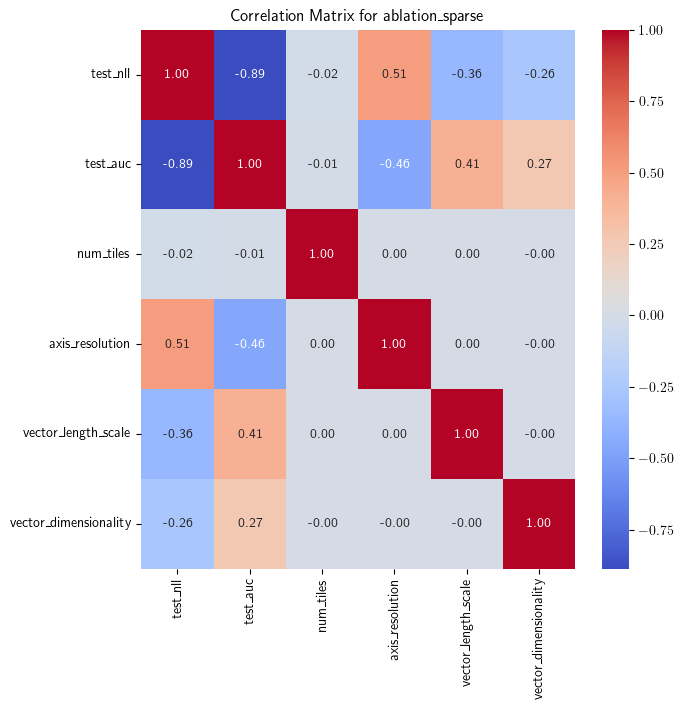

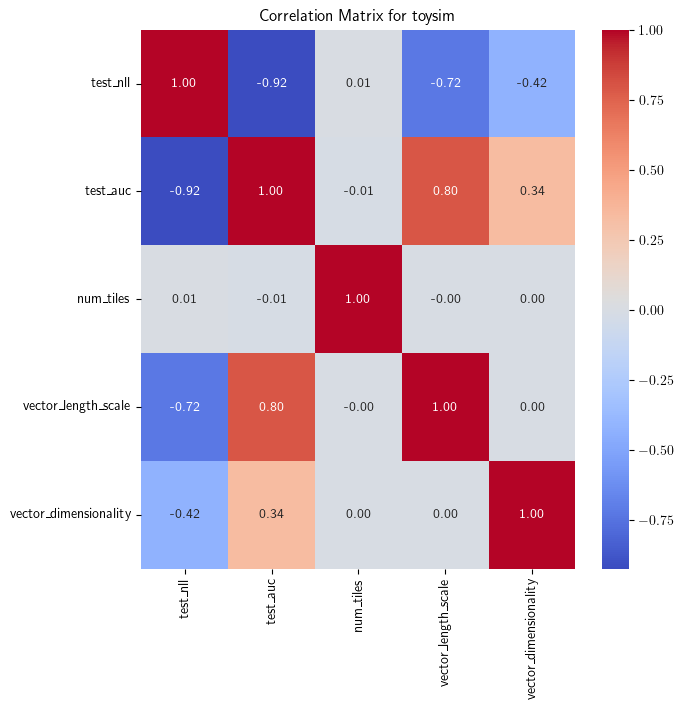

In [15]:
for key, df in data_frames.items():
    corr_matrix = df.corr()
    plt.figure(figsize=(7, 7))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title(f"Correlation Matrix for {key}")
    plt.savefig(f"exp2_correlation_matrix_{key}.svg")

In [ ]:
# create a box plot of vector dimensionality vs. test_auc for each dataset
for key, df in data_frames.items():
    plt.figure(figsize=(7, 7))
    sns.boxplot(x='vector_dim', y='test_auc', data=df)
    plt.title(f"Box Plot of Vector Dimensionality vs. Test AUC for {key}")
    plt.savefig(f"exp2_boxplot_vector_dim_vs_test_auc_{key}.svg")

In [ ]:
# create a box plot of vector dimensionality vs. test_nll for each dataset
for key, df in data_frames.items():
    plt.figure(figsize=(7, 7))
    sns.boxplot(x='vector_dim', y='test_nll', data=df)
    plt.title(f"Box Plot of Vector Dimensionality vs. Test NLL for {key}")
    plt.savefig(f"exp2_boxplot_vector_dim_vs_test_nll_{key}.svg")

In [ ]:
# create a box plot of length scale versus test_auc for each dataset
for key, df in data_frames.items():
    plt.figure(figsize=(7, 7))
    sns.boxplot(x='length_scale', y='test_auc', data=df)
    plt.title(f"Box Plot of Length Scale vs. Test AUC for {key}")
    plt.savefig(f"exp2_boxplot_length_scale_vs_test_auc_{key}.svg")

In [16]:
# create a box plot of length scale versus test_nll for each dataset
for key, df in data_frames.items():
    plt.figure(figsize=(7, 7))
    sns.boxplot(x='length_scale', y='test_nll', data=df)
    plt.title(f"Box Plot of Length Scale vs. Test NLL for {key}")
    plt.savefig(f"exp2_boxplot_length_scale_vs_test_nll_{key}.svg")

ValueError: Could not interpret value `length_scale` for `x`. An entry with this name does not appear in `data`.

<Figure size 700x700 with 0 Axes>

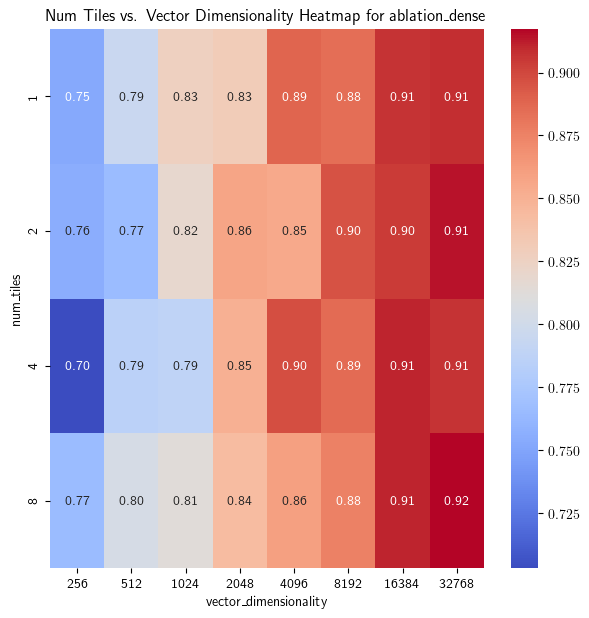

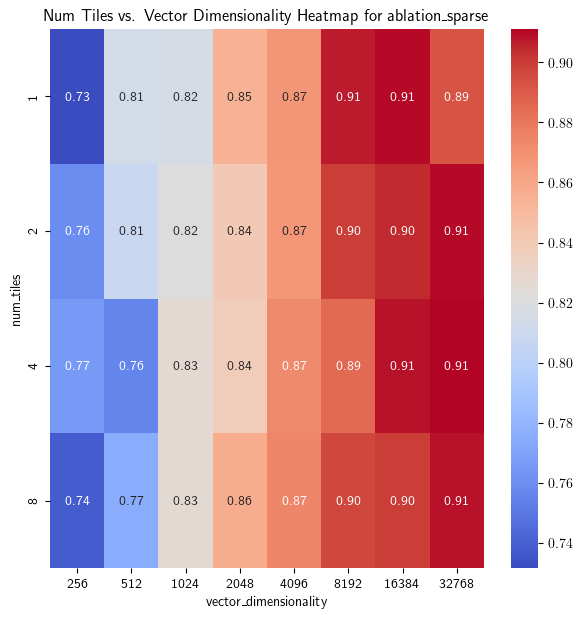

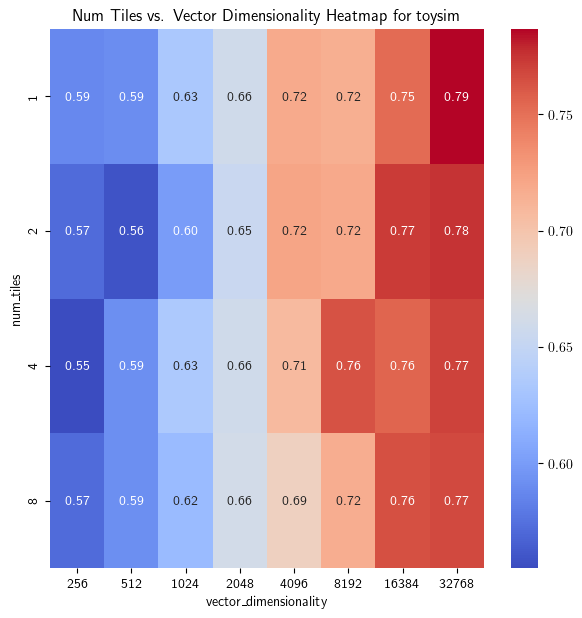

In [22]:
# plot num tiles versus vector dimensionality as a heatmap and hued by test_auc for each dataset
for key, df in data_frames.items():
    plt.figure(figsize=(7, 7))
    pivot_df = df.pivot_table(index='num_tiles', columns='vector_dimensionality', values='test_auc')
    sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title(f"Num Tiles vs. Vector Dimensionality Heatmap for {key}")
    plt.savefig(f"exp2_heatmap_num_tiles_vs_vector_dim_{key}.svg")

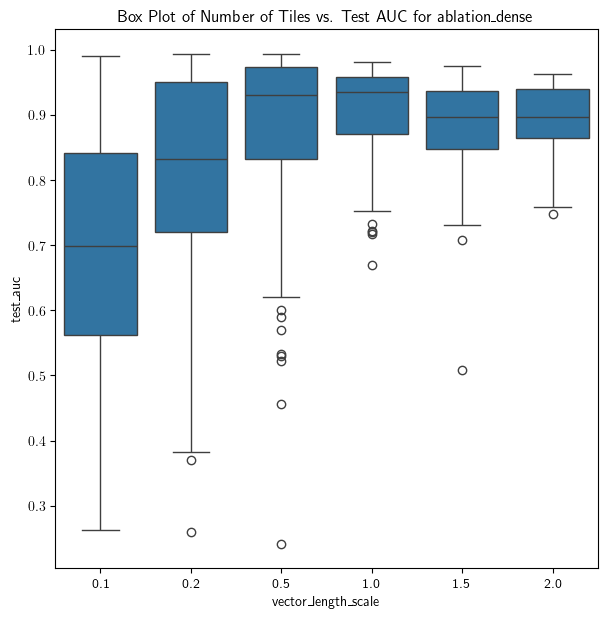

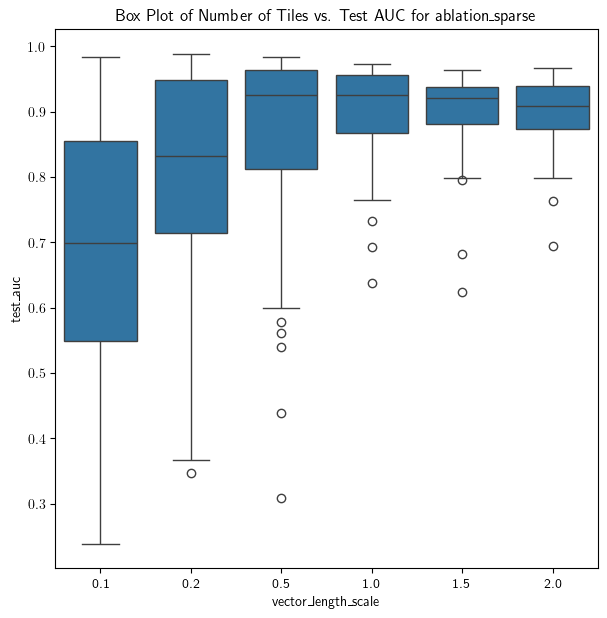

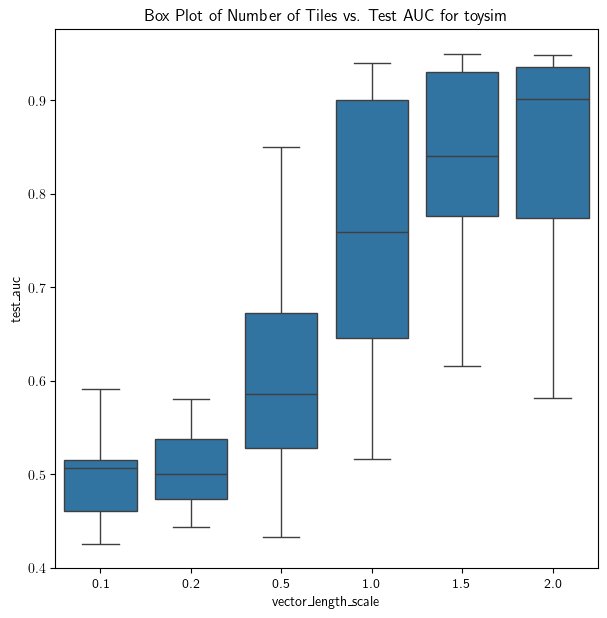

In [25]:
for key, df in data_frames.items():
    plt.figure(figsize=(7, 7))
    sns.boxplot(x='vector_length_scale', y='test_auc', data=df)
    plt.title(f"Box Plot of Number of Tiles vs. Test AUC for {key}")
    plt.savefig(f"exp2_boxplot_num_tiles_vs_test_auc_{key}.svg")

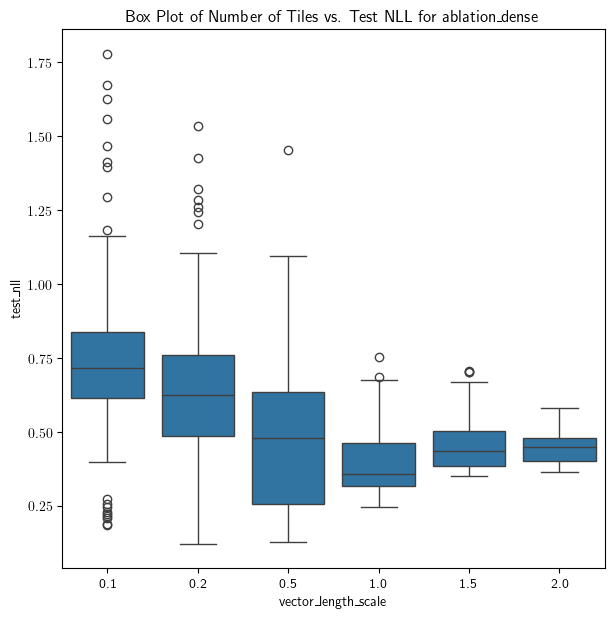

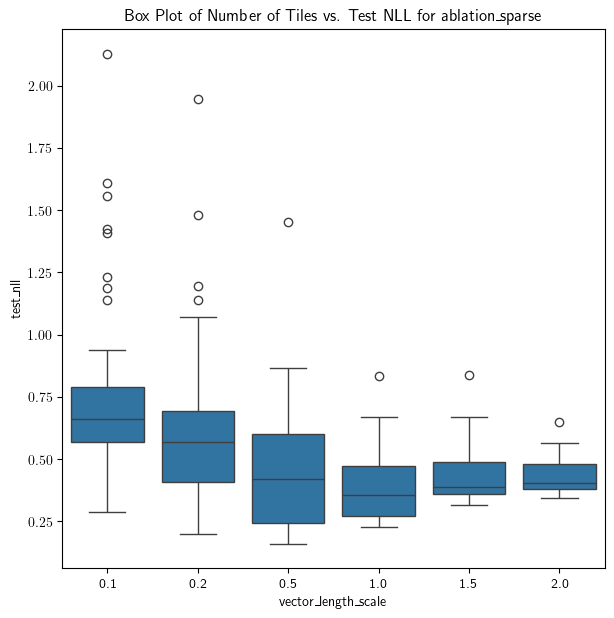

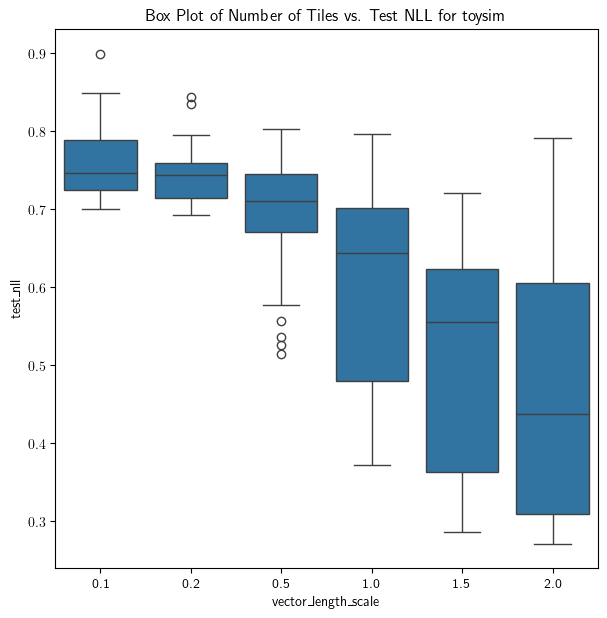

In [ ]:
for key, df in data_frames.items():
    plt.figure(figsize=(7, 7))
    sns.boxplot(x='vector_length_scale', y='test_nll', data=df)
    plt.title(f"Box Plot Vector Length Scale vs. Test NLL for {key}")
    plt.savefig(f"exp2_boxplot_length_scale_vs_test_nll_{key}.svg")

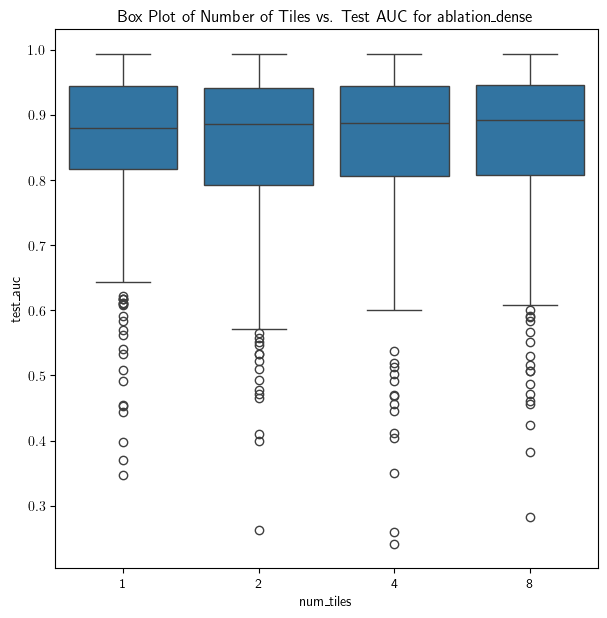

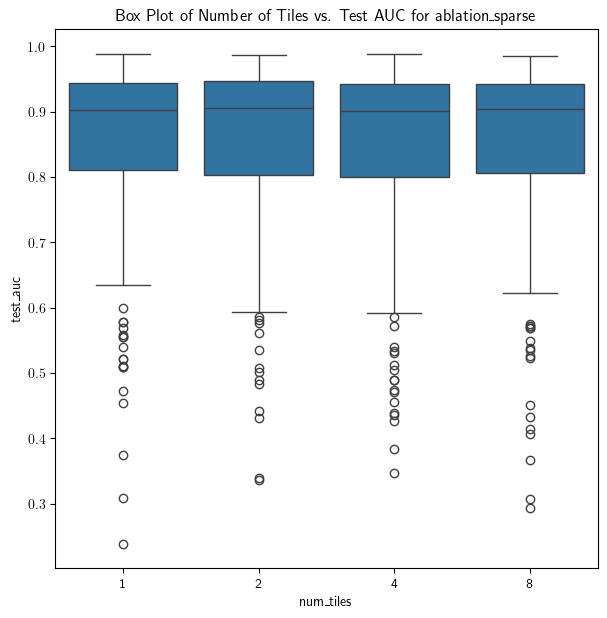

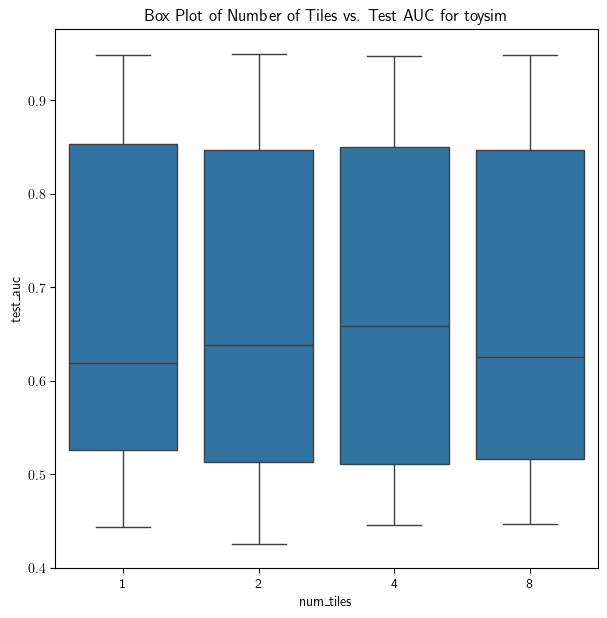

In [28]:
for key, df in data_frames.items():
    plt.figure(figsize=(7, 7))
    sns.boxplot(x='num_tiles', y='test_auc', data=df)
    plt.title(f"Box Plot of Number of Tiles vs. Test AUC for {key}")
    plt.savefig(f"exp2_boxplot_num_tiles_vs_test_auc_{key}.svg")

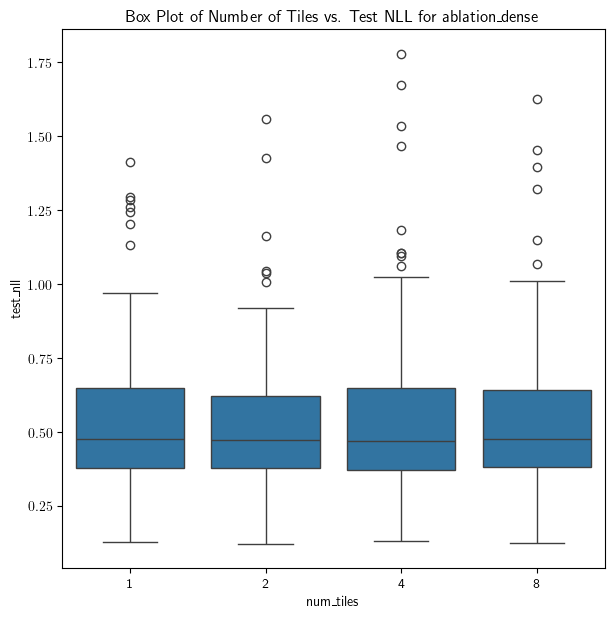

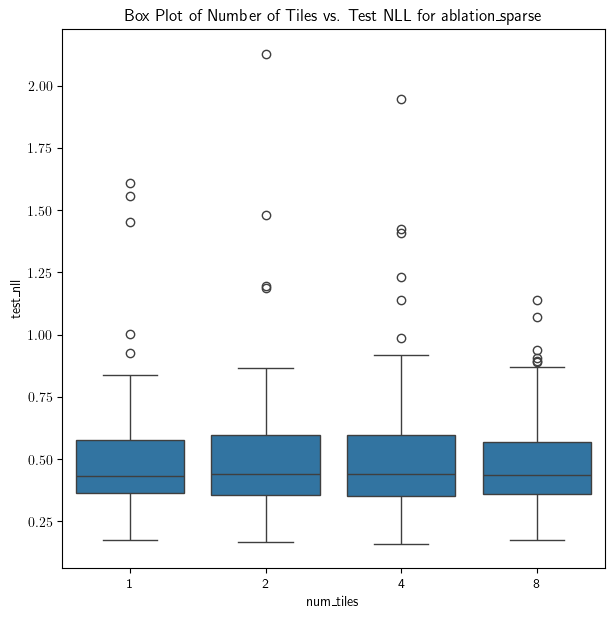

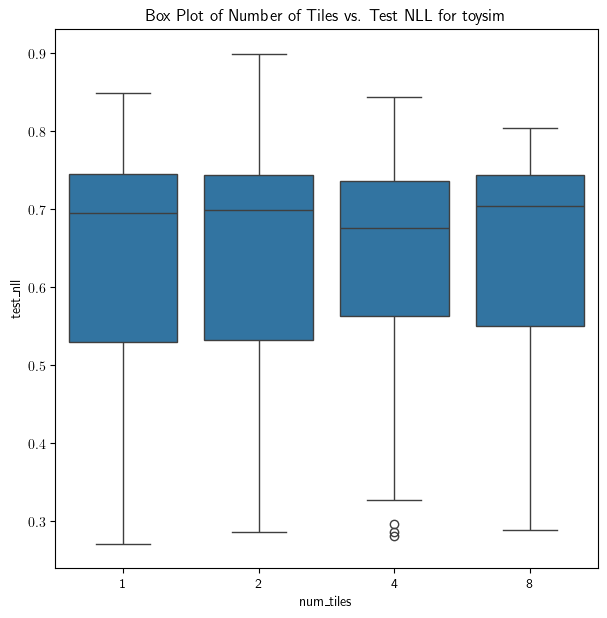

In [29]:
for key, df in data_frames.items():
    plt.figure(figsize=(7, 7))
    sns.boxplot(x='num_tiles', y='test_nll', data=df)
    plt.title(f"Box Plot of Number of Tiles vs. Test NLL for {key}")
    plt.savefig(f"exp2_boxplot_num_tiles_vs_test_nll_{key}.svg")